<a href="https://colab.research.google.com/github/ashras404/Student_Performance_Prediction_ML_Project/blob/main/Prediction_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files

# Upload the NEW Student_Performance.csv
uploaded = files.upload()

# Load it
df = pd.read_csv('Student_Performance.csv')
df.head()

Saving Student_Performance.csv to Student_Performance.csv


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
# Convert Yes to 1 and No to 0
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Check the first 5 rows to make sure it worked
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) from the target score (y)
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split! Training on {len(X_train)} rows.")

Data split! Training on 8000 rows.


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [ ]:
from sklearn.metrics import r2_score

# Predict the scores for our test set
y_pred = model.predict(X_test)

# Calculate the R2 Score
score = r2_score(y_test, y_pred)

print(f"R2 Score: {score:.4f}")
print(f"Accuracy Percentage: {score * 100:.2f}%")

R2 Score: 0.9890
Accuracy Percentage: 98.90%


In [ ]:
import numpy as np

# Format: [Hours Studied, Previous Scores, Extracurricular (1=Yes, 0=No), Sleep Hours, Question Papers Practiced]
my_stats = np.array([[8, 85, 1, 7, 5]])

# Make the prediction
my_prediction = model.predict(my_stats)

print(f"Predicted Performance Index: {my_prediction[0]:.2f}")

Predicted Performance Index: 80.25


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


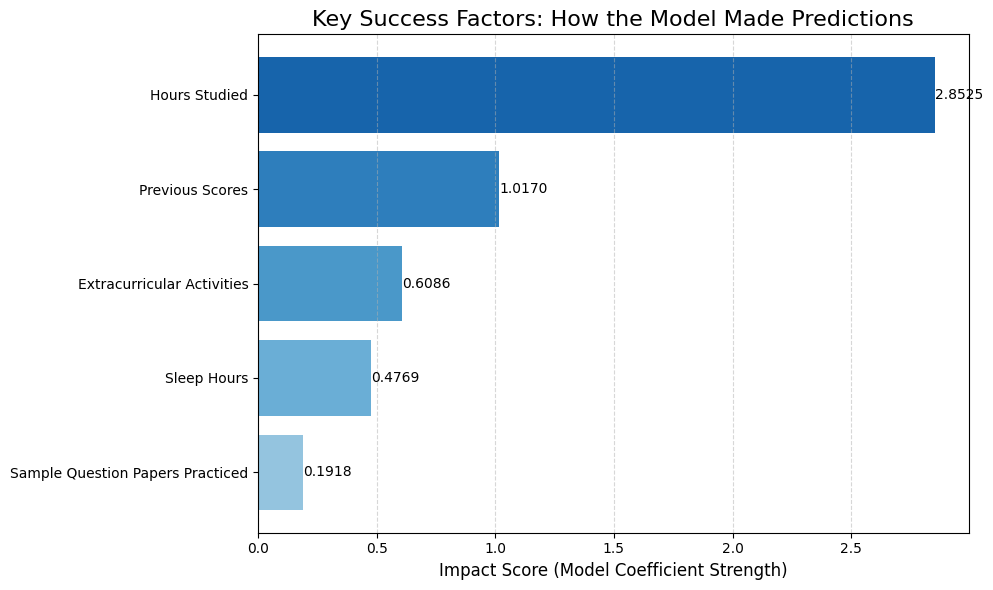

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get the feature importance (coefficients) from our model
# We must use absolute values to compare the "strength" of impact, regardless of direction
importances = np.abs(model.coef_)
feature_names = X.columns

# 2. Sort the features from most important to least important
sorted_indices = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_indices]
sorted_names = feature_names[sorted_indices]

# 3. Create the visualization
plt.figure(figsize=(10, 6))

# Use custom colors (professional blue/grey)
colors = plt.cm.Blues(np.linspace(0.8, 0.4, len(sorted_names)))
bars = plt.barh(sorted_names, sorted_importances, color=colors)

# Add numeric value labels at the end of each bar for clarity
plt.bar_label(bars, fmt='%.4f')

# Title and labels
plt.title("Key Success Factors: How the Model Made Predictions", fontsize=16)
plt.xlabel("Impact Score (Model Coefficient Strength)", fontsize=12)
plt.gca().invert_yaxis()  # Put the most important feature at the top
plt.grid(axis='x', linestyle='--', alpha=0.5)  # Add faint grid lines for readability

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# 1. Ask for a Row Index (0 to 9999)
row_index = int(input("Enter Student Index Number to lookup (0-9999): "))

# 2. Extract that specific student's features
student_data = X.iloc[[row_index]]
actual_score = y.iloc[row_index]

# 3. Get the Model's Prediction
predicted_score = model.predict(student_data)[0]

# 4. Display the comparison
print("-" * 30)
print(f"--- Student {row_index} Report ---")
print(student_data.to_string(index=False))
print("-" * 30)
print(f"ACTUAL Performance Index:    {actual_score}")
print(f"PREDICTED Performance Index: {predicted_score:.2f}")
print(f"Model Error:                 {abs(actual_score - predicted_score):.2f}")
print("-" * 30)

Enter Student Index Number to lookup (0-9999): 4
------------------------------
--- Student 4 Report ---
 Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  Sample Question Papers Practiced
             7               75                           0            8                                 5
------------------------------
ACTUAL Performance Index:    66.0
PREDICTED Performance Index: 67.09
Model Error:                 1.09
------------------------------
